# GARCH Models for Global Equity Indices

## Objective

Estimate conditional volatility models for four major equity indices and
compare **volatility persistence** across markets:

Index: 
- **S&P 500** : United States 
- **EURO STOXX 50** : Eurozone 
- **Nikkei 225** : Japan 
- **FTSE 100** : United Kingdom 

## The model

Financial returns exhibit **volatility clustering** — large moves tend to
be followed by large moves. A constant-variance model cannot capture this.
GARCH(1,1) specifies the conditional variance as a function of both the
previous shock and the previous variance:

$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

| Parameter | Name | Interpretation |
|---|---|---|
| $\omega$ | constant | Baseline variance level |
| $\alpha$ | **ARCH term** | Reaction to yesterday's shock (news impact) |
| $\beta$ | **GARCH term** | Memory of yesterday's variance |
| $\alpha + \beta$ | **persistence** | How slowly volatility mean-reverts |

Persistence is the central quantity of this project. Values close to 1
imply shocks to volatility decay very slowly; the **half-life** of a
volatility shock is $\ln(0.5) / \ln(\alpha + \beta)$ trading days.

## Sample period

**2005-01-01 to present.** Chosen deliberately to span four distinct
volatility regimes:

- **2008** — Global Financial Crisis (credit-driven, global)
- **2011** — European Sovereign Debt Crisis (regional, asymmetric across markets)
- **2020** — COVID crash (globally synchronised, extremely fast)
- **2022** — Inflation and rate-hike shock (slow-moving, persistent)

A shorter window (e.g. 2015–2025) would contain only one major event,
making cross-market differences difficult to identify.

## Roadmap

| Stage | Content | Question answered |
|---|---|---|
| **1** | Data acquisition, log returns, summary statistics | What does the raw data look like, and is it clean? |
| **2** | Exploratory analysis, ARCH-LM and Ljung-Box tests | Is a constant-variance model rejected by the data? |
| **3** | GARCH(1,1) estimation | How large are $\alpha$, $\beta$, and persistence in each market? |
| **4** | Distributional assumptions: Normal vs Student-$t$ | Do the standardised residuals still show fat tails? |
| **5** | Asymmetric extensions: GJR-GARCH, EGARCH | Do negative shocks raise volatility more than positive ones? |
| **6** | Diagnostics and cross-market comparison | Which market's volatility is most persistent, and why? |
| **7** | VaR backtesting | Does the model produce risk numbers that survive validation? |

Each stage ends with a saved figure or results table in `outputs/`.

# Stage 1 — Data

**Goal.** Obtain clean, comparable return series for four equity indices
and establish the stylised facts that motivate volatility modelling.

**Steps.** Download prices → convert to percentage log returns →
verify data integrity → cache a snapshot for reproducibility.

**Key design decisions.**
1. No calendar alignment — each index keeps its own trading days.
2. Common start date of 2007-04-01, imposed by `^STOXX50E` availability.
3. Returns scaled by 100 for numerical stability of the MLE optimiser.

**Outcome.** Four series of ~4,800 observations each, all displaying
excess kurtosis and negative skewness — the empirical signature that
motivates Stage 2.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import(
    INDICES,
    download_index_prices,
    compute_log_returns,
    summary_statistics,
    save_returns,
)

from src.plots import (
    plot_prices,
    plot_returns,
    plot_rolling_volatility,
    plot_return_distributions,
)

from src.plots import (
    plot_prices,
    plot_returns,
    plot_rolling_volatility,
    plot_rolling_volatility_panels,     # 新增
    plot_return_distributions,
)

from src.diagnostics import arch_lm_test, ljung_box_test

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

from src.garch_models import (
    fit_garch,
    fit_all,
    half_life,
    summarise_fits,
    parameter_significance,
)

from src.plots import (
    plot_prices,
    plot_returns,
    plot_rolling_volatility,
    plot_rolling_volatility_panels,
    plot_return_distributions,
    plot_conditional_volatility,       
)

from src.plots import plot_residual_qq

print("Imports OK")

Imports OK


## 1.1 Data acquisition

**Design decision: no calendar alignment.**

The four markets trade on different calendars ： Japan has Golden Week, the UK has bank holidays, the US has Thanksgiving. Merging them into one DataFrame and dropping incomplete rows would discard observations *systematically*, not at random.

More importantly, GARCH models a **recursive** relationship: $\sigma_t^2$ depends on $\sigma_{t-1}^2$. Deleting arbitrary days breaks that recursion and biases the persistence estimate ： precisely the quantity this project sets out to measure.

Each index is therefore kept as an independent series with its own calendar, stored in a `dict` rather than a `DataFrame`.

In [2]:
# Download prices and compute log returns

prices = download_index_prices(start="2007-04-01")
# Downloads each ticker independently; the function prints obs count and date range.

returns = compute_log_returns(prices)
# dict[label] -> Series of percentage log returns

# Confirm we have Series, not DataFrames (i.e. that .squeeze() did its job)
print()
for label, r in returns.items():
    print(f"{label:8s} {type(r).__name__:10s} {len(r):>5,} obs")

SPX      4,893 obs   2007-04-02 -> 2026-09-11
SX5E     4,875 obs   2007-04-02 -> 2026-09-11
Nikkei   4,756 obs   2007-04-02 -> 2026-09-11
FTSE     4,911 obs   2007-04-02 -> 2026-09-11

SPX      Series     4,892 obs
SX5E     Series     4,874 obs
Nikkei   Series     4,755 obs
FTSE     Series     4,910 obs


**2007-04-01 to present**, chosen to span four distinct volatility regimes.
The start date is set by data availability for `^STOXX50E` 

### 1.2 Quantifying the cost of alignment

The previous section argued against calendar alignment on methodological
grounds. Here we measure what it would actually cost in observations,
turning a design choice into an evidenced one.

In [3]:
# How much data would calendar alignment destroy?

# pd.DataFrame(dict_of_series) performs an outer join on the date index.
# A market closed on a given day produces a NaN in its column.
df_aligned = pd.DataFrame(returns).dropna()   # keep only days when ALL four traded

print(f"{'Index':8s} {'Standalone':>12s} {'Aligned':>10s} {'Lost':>8s} {'Loss %':>8s}")
print("-" * 52)
for label, r in returns.items():
    lost = len(r) - len(df_aligned)
    print(f"{label:8s} {len(r):>12,} {len(df_aligned):>10,} {lost:>8,} {lost/len(r):>7.1%}")

Index      Standalone    Aligned     Lost   Loss %
----------------------------------------------------
SPX             4,892      4,445      447    9.1%
SX5E            4,874      4,445      429    8.8%
Nikkei          4,755      4,445      310    6.5%
FTSE            4,910      4,445      465    9.5%


**Result.** Alignment would reduce the common sample to 4,441 observations,
costing between 6.5% and 9.5% of each series.

Note the ordering: the Nikkei loses the *least* in percentage terms
despite Japan having the most public holidays. This is because alignment
takes the intersection： the Nikkei's own holidays already shorten its
standalone series, while the FTSE, which is the longest, absorbs the most
cuts from other markets' calendars.

The count is only part of the argument. The days removed are not random:
holidays cluster (Golden Week, Christmas, Easter), so alignment deletes
contiguous blocks rather than scattered days, severing the variance
recursion $\sigma_t^2 = f(\sigma_{t-1}^2, \epsilon_{t-1}^2)$ across each gap.

## 1.3 Summary statistics

Three quantities make the empirical case for GARCH *before* any model is fitted:

| Statistic | What to look for | Why it matters |
|---|---|---|
| **Excess kurtosis** | Typically 8–15 for daily equity indices | Normal implies 0. Fat tails motivate **Student-t innovations** (Stage 4). |
| **Skewness** | Usually negative | Crashes are sharper than rallies — motivates **GJR-GARCH** (Stage 5). |
| **Jarque–Bera p-value** | Essentially 0 | Formally rejects normality of unconditional returns. |

Note that fat tails alone do **not** prove volatility clustering — i.i.d. draws from a
$t$-distribution would also show excess kurtosis. The formal test for clustering
(**ARCH-LM**) comes in the next section.

In [4]:
# Cell 3 — Summary statistics
stats_table = summary_statistics(returns)
stats_table

,N,Start,End,Mean,Std,Ann. Vol (%),Skew,Excess Kurt,Min,Max,JB p-value
Index,,,,,,,,,,,
SPX,4892,2007-04-03,2026-09-11,0.0344,1.2462,19.7836,-0.4683,12.4719,-12.7652,10.9572,0.0000
SX5E,4874,2007-04-03,2026-09-11,0.0085,1.3717,21.7755,-0.3032,7.7136,-13.2405,10.4376,0.0000
Nikkei,4755,2007-04-03,2026-09-11,0.0278,1.5084,23.9459,-0.4433,8.2128,-13.2341,13.2346,0.0000
FTSE,4910,2007-04-03,2026-09-11,0.0106,1.1230,17.8276,-0.4284,10.3690,-11.5117,9.3842,0.0000


**Findings.**

All four series display the classic stylised facts of daily equity returns:

- **Excess kurtosis of 7.7–12.5** (normal implies 0). Under normality, a
  12.8% daily move would be a roughly 10-sigma event; the sample contains
  one. SPX has the *highest* kurtosis despite the *lowest* volatility：
  calm on average, but with the most concentrated tail risk.
- **Negative skewness throughout** (−0.30 to −0.47), consistent with the
  leverage effect: declines raise leverage, which raises volatility.
  Symmetric GARCH cannot capture this, motivating GJR in Stage 5.
- **Jarque–Bera rejects normality** for every index at any conventional level.

**Volatility ranking:** Nikkei (23.9%) > SX5E (21.8%) > SPX (19.8%) > FTSE (17.8%).
Whether this *unconditional* ranking matches the ranking of *persistence*
is an open question ： high volatility and persistent volatility are
distinct properties. We return to this after estimation.

**A caveat on interpretation.** Jarque–Bera tests the *unconditional*
distribution. A GARCH process with perfectly Gaussian innovations still
produces fat unconditional tails, because mixing normals with
time-varying variance generates excess kurtosis. This table therefore
establishes non-normality but does not by itself justify Student-t
innovations ： that case rests on the *standardised* residuals after
fitting, examined in Stage 4.

## 1.4 Caching the return series

Yahoo Finance revises historical data over time ： index reconstitution,
vendor corrections, and adjustment changes all shift values retroactively.
Caching a snapshot is what makes the reported results reproducible: a
reader running this notebook next year should obtain the same numbers.

The saved file is a wide CSV with one column per index. **NaNs in it are
expected** ： they mark days on which a given market was closed. When
reading the file back, extract each column and drop NaNs individually
rather than dropping rows from the whole frame, which would silently
impose the calendar alignment we rejected above.

In [5]:
# persist the return series
df_returns = save_returns(returns, path="../data/index_returns.csv")
# Wide CSV: one row per calendar date, one column per index.
# NaN = that market was closed. This is the expected structure, not a defect.

print(f"Saved: {df_returns.shape[0]:,} rows x {df_returns.shape[1]} columns")
print(f"Date range: {df_returns.index[0].date()} -> {df_returns.index[-1].date()}")
print()

# Per-column non-null counts should match the standalone obs counts from Cell 1.
# If they don't, something was lost in the round trip.
print("Non-null observations per column:")
print(df_returns.count())

Saved: 5,057 rows x 4 columns
Date range: 2007-04-03 -> 2026-09-11

Non-null observations per column:
SPX       4892
SX5E      4874
Nikkei    4755
FTSE      4910
dtype: int64


# Stage 2 — Exploratory Analysis and Formal Tests

**Goal.** Establish that the data *requires* a time-varying variance
model, rather than assuming it.

Most treatments of GARCH begin by fitting the model. That skips the
question a reader should ask first: how do we know a constant-variance
specification is inadequate? This stage answers it in two ways.

**Visual evidence (§2.1–2.4).** Price levels, return series, rolling
volatility, and distribution plots. These make volatility clustering and
fat tails visible, but visual patterns are suggestive rather than
conclusive.

**Formal evidence (§2.5).** Two tests convert the visual impression into
a testable claim:

- **ARCH-LM test** (Engle 1982) — $H_0$: no ARCH effects, i.e. the
  conditional variance is constant. Rejection is the formal licence to
  fit GARCH.
- **Ljung–Box test** — applied to $r_t$ and to $r_t^2$ separately. The
  expected pattern is *no* significant autocorrelation in returns
  (consistent with weak-form market efficiency) but *strong*
  autocorrelation in squared returns. That contrast is the entire
  rationale for GARCH: the direction of returns is unpredictable, their
  magnitude is not.

**Outcome.** A documented basis for the modelling choices in Stage 3.

## 2.1 Price levels

The first check is on the data itself. All four indices are rebased to
100 at the sample start so they can share one axis despite trading at
very different levels. E.g. the Nikkei in the tens of thousands, the FTSE in
the thousands.

What we are looking for here is not a result but the *absence* of
problems: no flat stretches (stale data), no vertical jumps
(unadjusted splits or vendor errors), no gaps. Anything unusual should
be caught now, before it contaminates the variance estimates downstream.

Shaded bands mark the four crisis windows the sample was chosen to span.
Their placement lets the reader verify later claims about volatility
spikes against specific events rather than taking them on trust.


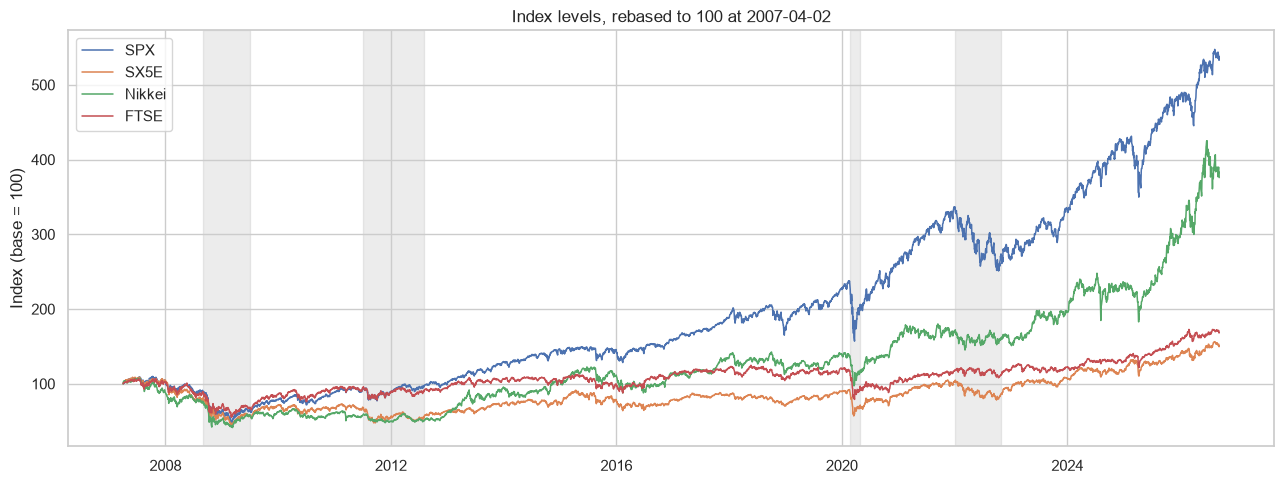

In [6]:
# Index price levels
plot_prices(prices, save_path="../outputs/index_prices.png")

**Data integrity.** All four series are continuous with no flat stretches,
vertical jumps, or gaps. The data is clean enough to model.

**Crisis synchronicity differs by episode.** In 2008 and 2020 all four
indices fall together : these were global shocks transmitted through
credit markets and a pandemic respectively. The 2011 European sovereign
debt window is different: SX5E and the Nikkei decline visibly while SPX
is roughly flat over the same period.

This asymmetry is worth flagging early. It suggests that volatility
dynamics are not simply a global factor scaled up and down by market, and
that the cross-market comparison in Stage 6 has something real to
measure.

**Long-run drift is irrelevant here.** SPX ends near 540 while SX5E ends
near 150, but GARCH models the *second* moment. The dispersion in
cumulative performance tells us nothing about which market has the more
persistent volatility, that is precisely the question estimation will
answer.

## 2.2 Return series

This is the single most informative plot in the exploratory section.

That persistence of the widening is the point. A single large move is
just an outlier. Large moves *arriving in clusters* is a statement about
the conditional variance process, and it is what GARCH is built to
capture.

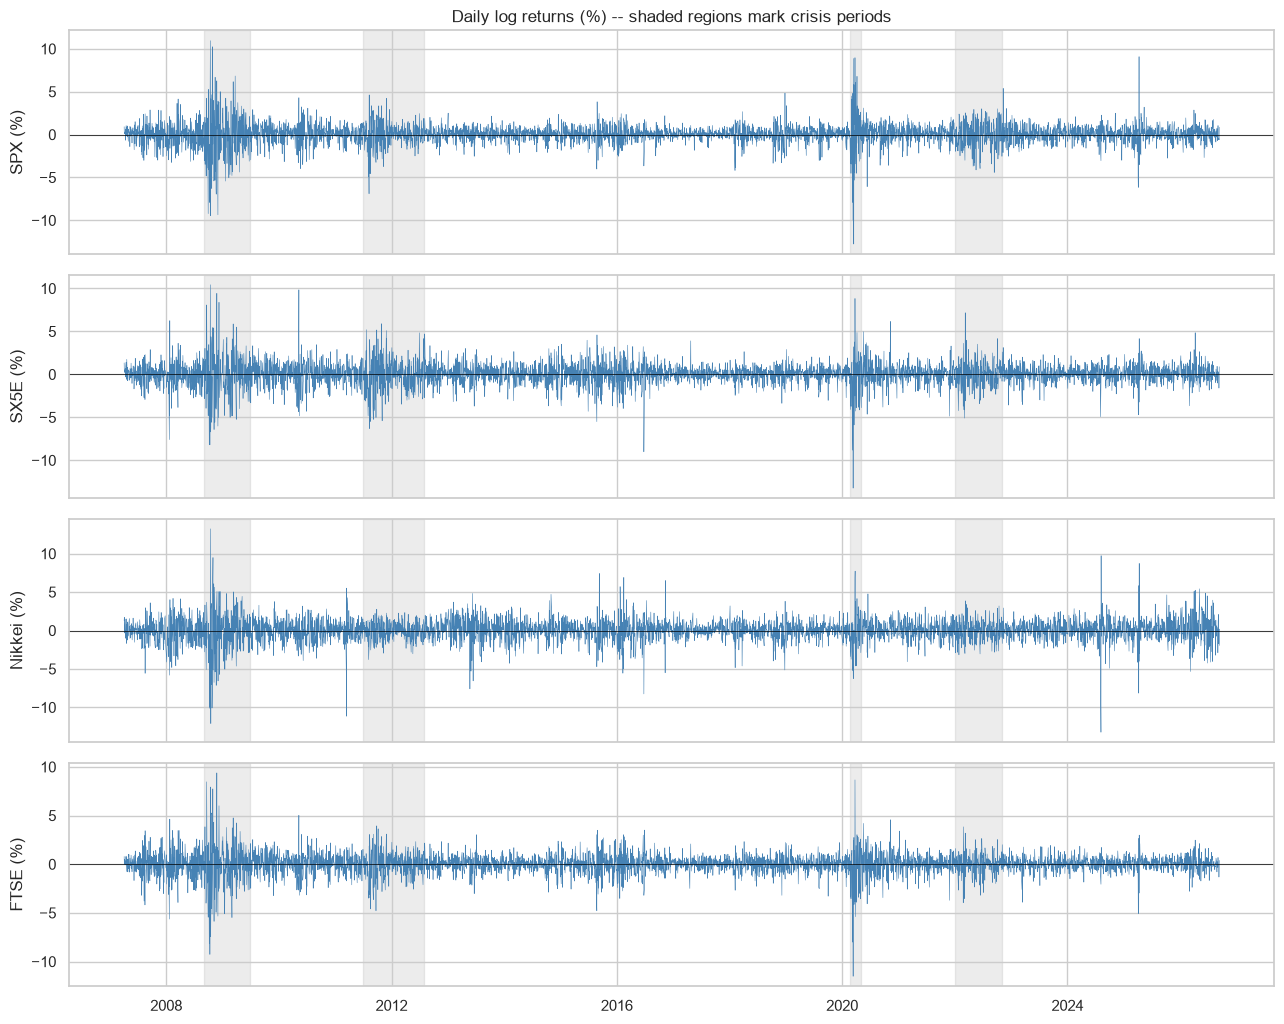

In [7]:
# Daily return series
plot_returns(returns, save_path="../outputs/returns_timeseries.png")

**Volatility clustering is unambiguous.** Every panel shows the same
structure: long stretches of thin, stable amplitude interrupted by
episodes where the band widens sharply and *remains* wide for weeks or
months. A constant-variance model cannot generate this pattern.

**The two global crises have different shapes.** The 2008 episode builds
gradually, stays elevated for roughly a year, and decays slowly. The 2020
episode is near-vertical — peak amplitude within weeks — and decays
considerably faster. These correspond to different parameter
configurations: a fast, violent onset requires a large $\alpha$ (strong
reaction to shocks), while a long tail requires a large $\beta$ (long
memory). Whether estimation reproduces this distinction is worth checking.

**2011 confirms the regional asymmetry.** SX5E and FTSE widen visibly
during the sovereign debt window; SPX reacts more mildly and the Nikkei
barely at all.

**The Nikkei has an idiosyncratic elevated regime.** Between roughly 2013
and 2016 its band is persistently wide while the other three are calm.
This coincides with Abenomics and aggressive Bank of Japan easing,
suggesting the Nikkei's high unconditional volatility (23.9%) is not
driven by crises alone but partly by domestic policy regime. The isolated
−12% spike in August 2024 — the yen carry-trade unwind — is a further
Japan-specific event with no counterpart in the other series.

### 2.3 Rolling volatility

The return plot shows clustering qualitatively; this one puts a number on
it. A 21-day rolling standard deviation, annualised by $\sqrt{252}$, gives
a readable volatility *level* at each point in time.

The window length is a trade-off. Too short and the estimate is noisy;
too long and it smooths away the regime shifts we are trying to see. 21
trading days is one calendar month, which is responsive enough to track the onset
of a crisis, stable enough to interpret.

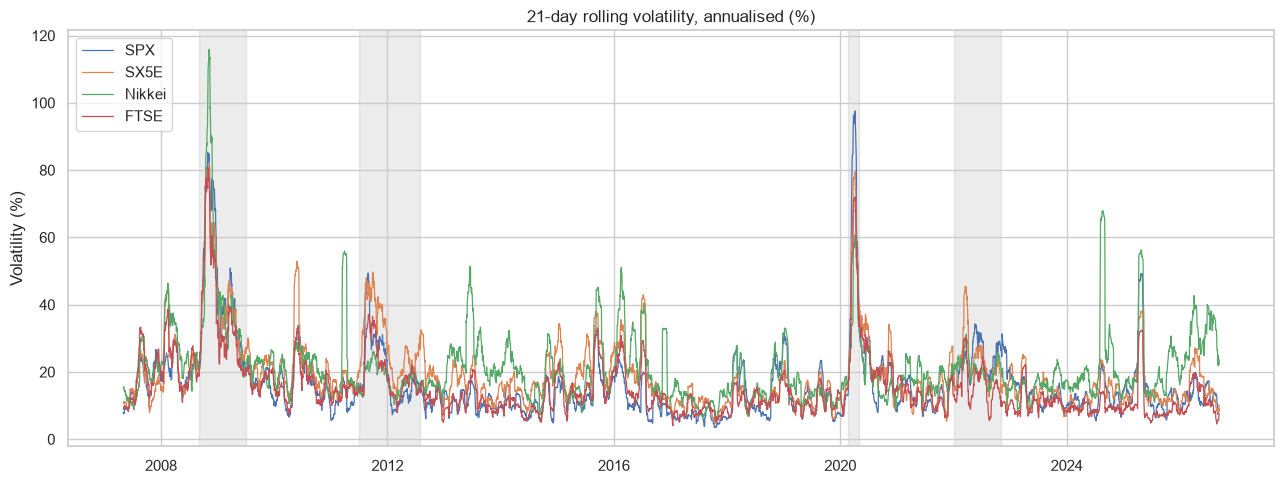

In [8]:
# Rolling volatility
plot_rolling_volatility(returns, window=21,
                        save_path="../outputs/rolling_volatility.png")

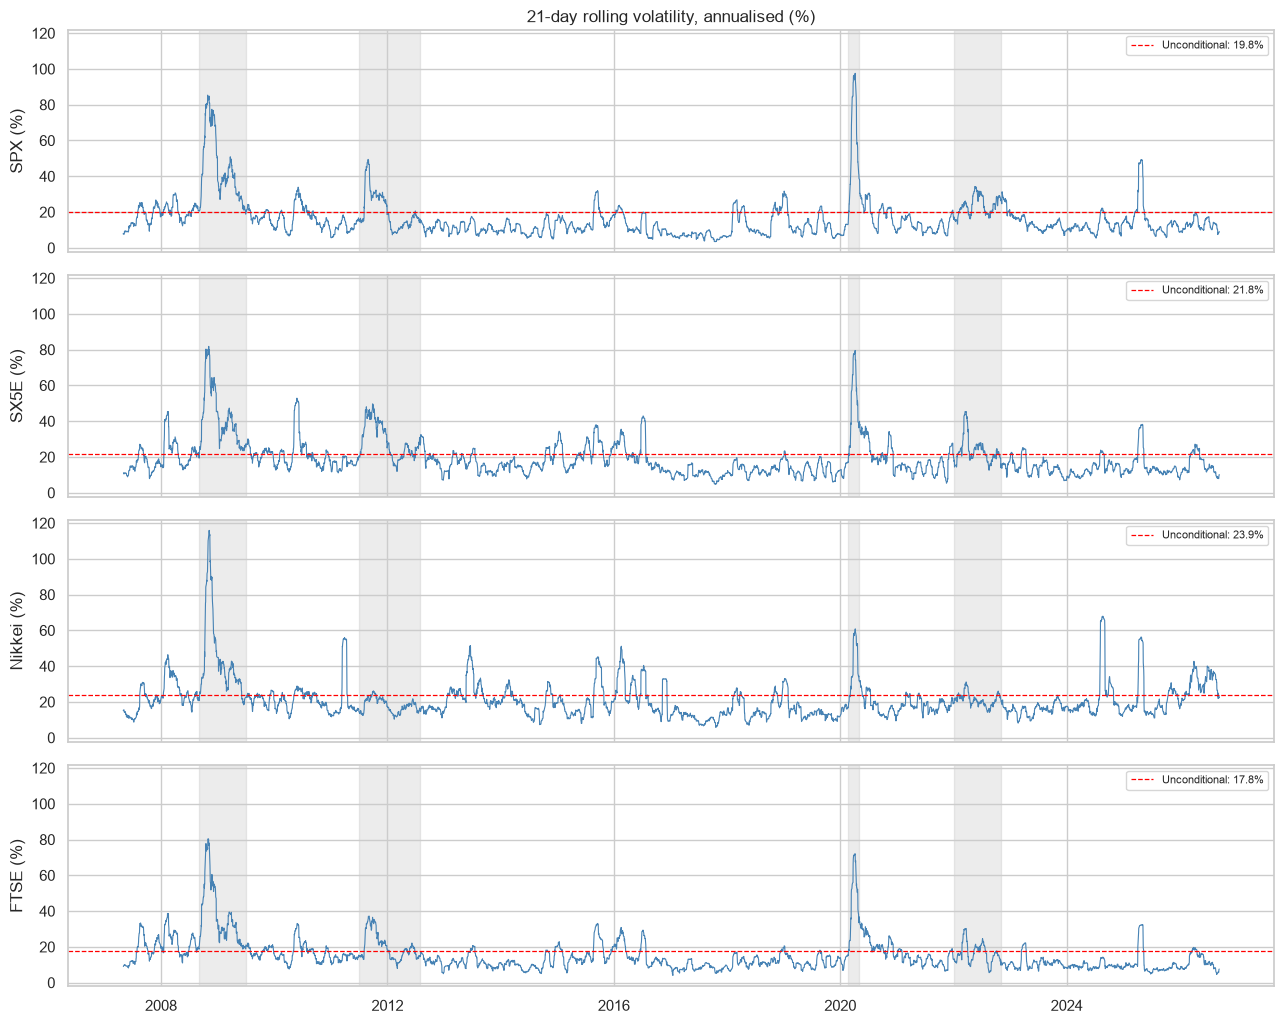

In [9]:
# Rolling volatility, separate panels
plot_rolling_volatility_panels(returns, window=21,
                               save_path="../outputs/rolling_volatility_panels.png")

**Volatility spans more than a factor of ten.** The baseline in calm
periods is 10–15% annualised; the 2008 peak reaches 115% for the Nikkei
and the 2020 peak reaches 97% for SPX. 

**The two global crises have distinct shapes.** 2008 produces a broad
plateau: volatility stays between 40% and 60% for roughly nine months
before subsiding. 2020 is a spike: a higher peak, but back near 20%
within a few months. This is the visual signature of the $\alpha$ / $\beta$
distinction.

**The Nikkei's excess volatility is not crisis-driven.** The green line
sits above the others through 2013–2016 and again from 2024 onward,
periods in which the other three indices are calm. These correspond to
Abenomics-era monetary expansion and to the 2024 exit from negative
rates, which triggered the carry-trade unwind visible as the isolated
67% spike. Japan's rank as the most volatile market therefore reflects a
domestic policy regime.

**2011 is regional.** SX5E reaches roughly 50% during the sovereign debt
window while SPX stays near 30%

## 2.4 Return distributions

The previous plots characterise volatility through time. This one
characterises the *shape* of the return distribution, which determines how
extreme the extremes can be.

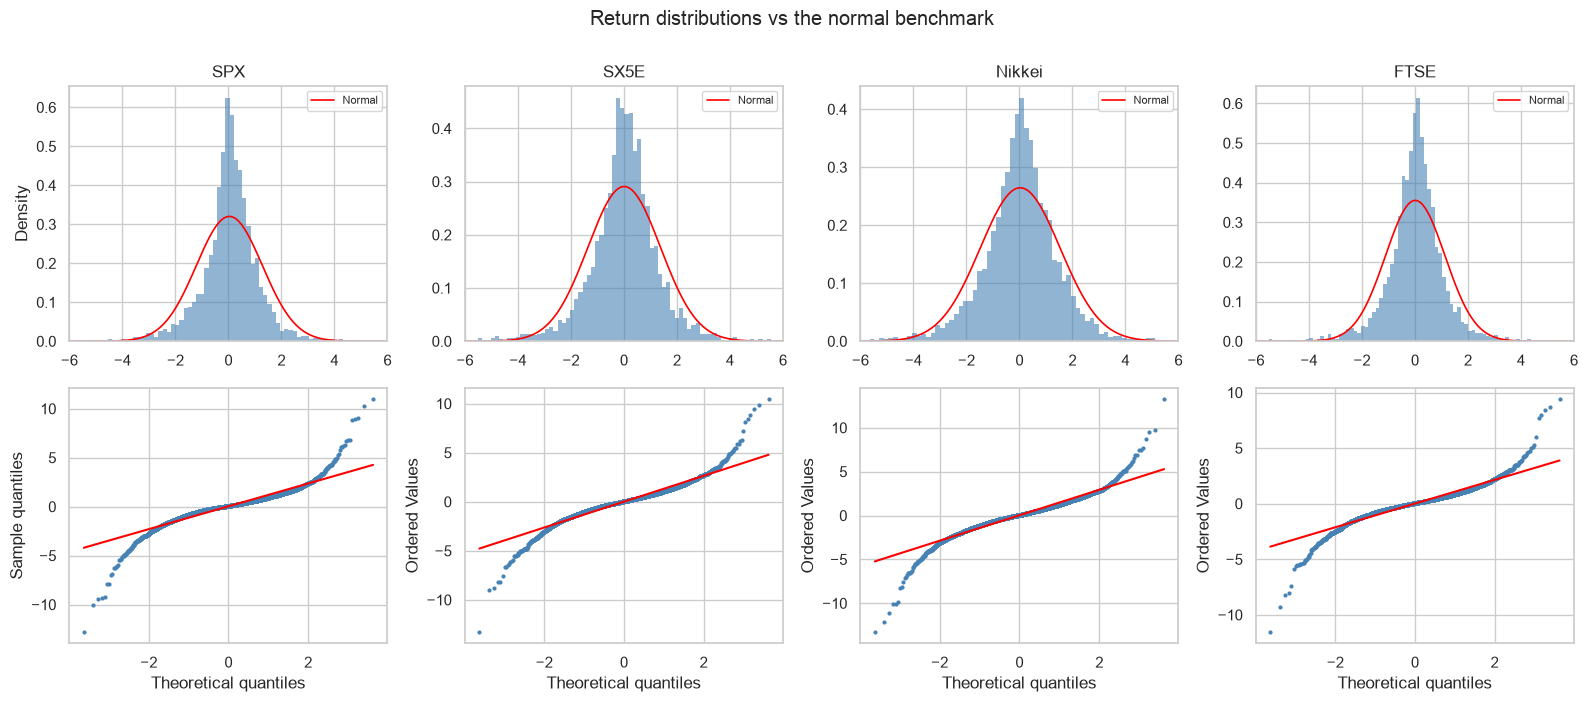

In [10]:
# Return distributions vs the normal benchmark
plot_return_distributions(returns,
                          save_path="../outputs/return_distributions.png")

**The histogram shows both sides of fat tails.** 
Fat-tailed return distributions are therefore better described in three
parts: more very quiet days than normality predicts, fewer moderate days,
and far more extreme days. 

**The QQ plots show where normality actually fails.** Between roughly
$-2$ and $+2$ theoretical quantiles, all four series lie almost exactly on
the reference line. The normal approximation is adequate for about 95% of
observations.

**The departure is asymmetric.** The left tail pulls away from the line
more sharply than the right in every panel.

**Implication for risk measurement.** A 95% VaR computed under normality
would be roughly adequate, since the 5% quantile still sits close to the
line. A 99% VaR would not. This is one reason regulatory frameworks
specify the higher confidence level, and it is precisely where the Gaussian
approximation stops working.

## 2.5 Formal specification tests
**ARCH-LM test (Engle 1982).** Regress squared demeaned returns on their
own lags. Under the null of no ARCH effects — a constant conditional
variance — every slope is zero and $T \cdot R^2 \sim \chi^2_q$. Rejection
is the formal justification for a conditional variance model.

**Ljung–Box test.** Applied separately to $r_t$ and $r_t^2$. The pattern
we expect is the following:

| Series | Expected result | Interpretation |
|---|---|---|
| $r_t$ | No significant autocorrelation | Direction is unpredictable — weak-form efficiency |
| $r_t^2$ | Strong autocorrelation | Magnitude *is* predictable — volatility clusters |

In [11]:
# ARCH-LM test
arch_results = arch_lm_test(returns, lags=(1, 5, 10, 22))
arch_results

/Users/huang/Desktop/StockMarket Projects/garch_project/.venv/lib/python3.11/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


LM stat    R^2  p-value  Reject H0 at 1%
Index  Lags                                            
SPX    1      511.4359  10.5%   0.0000             True
       5    1,293.9440  26.5%   0.0000             True
       10   1,372.3266  28.1%   0.0000             True
       22   1,466.6633  30.0%   0.0000             True
SX5E   1      123.5423   2.5%   0.0000             True
       5      706.2174  14.5%   0.0000             True
       10     780.2967  16.0%   0.0000             True
       22     829.0831  17.0%   0.0000             True
Nikkei 1      563.9794  11.9%   0.0000             True
       5      880.4867  18.5%   0.0000             True
       10     963.7716  20.3%   0.0000             True
       22     996.9200  21.0%   0.0000             True
FTSE   1      231.6709   4.7%   0.0000             True
       5      941.2525  19.2%   0.0000             True
       10   1,024.6542  20.9%   0.0000             True
       22   1,084.5349  22.1%   0.0000             True

**H0 is rejected in all sixteen tests.** Every $p$-value is
indistinguishable from zero. 

**The statistic rises monotonically with lag length.** The latter has a
one-day memory and cannot generate dependence at these horizons without
a large number of lags.

**The cross-sectional pattern is informative.** SPX has the *lowest*
unconditional volatility but the *highest* one-lag LM statistic (511
against 123 for SX5E), consistent with its being the calmest market on
average while reacting most sharply to shocks. SX5E shows the opposite profile:
a weak immediate response but the largest proportional increase from one
lag to five.


In [12]:
# Ljung-Box test on returns vs squared returns
lb_results = ljung_box_test(returns, lags=(5, 10, 22))
lb_results

Q(r)   p(r)     Q(r^2)  p(r^2)
Index  Lags                                   
SPX    5     80.4116 0.0000 2,772.4016  0.0000
       10   115.0006 0.0000 4,729.0381  0.0000
       22   172.3652 0.0000 6,831.1531  0.0000
SX5E   5     18.7000 0.0022 1,197.4592  0.0000
       10    33.8761 0.0002 1,900.1811  0.0000
       22    47.9856 0.0011 2,771.6047  0.0000
Nikkei 5     17.9351 0.0030 1,770.2849  0.0000
       10    20.4676 0.0251 2,633.1841  0.0000
       22    44.2696 0.0033 3,512.6762  0.0000
FTSE   5     27.7922 0.0000 1,772.6556  0.0000
       10    45.0442 0.0000 2,910.4296  0.0000
       22    70.3793 0.0000 4,543.9876  0.0000

**The contrast between the two columns is the result.** At twenty-two
lags, the Ljung–Box statistic on squared returns exceeds that on returns
by a factor of 40 (SPX) to 81 (Nikkei). Direction carries little
exploitable structure; magnitude carries a great deal. That asymmetry is
the entire justification for modelling the conditional variance while
leaving the conditional mean as a constant.

**Returns are not, however, serially independent.** $Q(r)$ is significant
at conventional levels for most index–lag combinations, which deserves an
explanation rather than being passed over.

Three factors contribute. 

1） **non-synchronous
trading**: an index aggregates hundreds of constituents that do not trade
simultaneously, so information propagates into the index with a lag,
inducing spurious positive autocorrelation at the index level (Lo and
MacKinlay, 1990). 

2） **sample size**: with $N \approx 4{,}900$,
inverting $Q \approx N\sum\rho_k^2$ implies an average
$|\rho_k| \approx 0.04$ for SPX. That is statistically significant and
economically meaningless — it would not survive bid-ask spreads, let
alone transaction costs. 

3） **short-horizon reversal during crises**,
where sharp declines are frequently followed by sharp rebounds.

**Consequence for specification.** Strictly, significant $Q(r)$ argues for
an AR term in the mean equation. In practice an AR(1) coefficient of 0.04
explains under 0.2% of return variance, leaving residuals almost identical
to demeaned returns. We therefore retain a constant mean throughout, and
verify in Stage 6 that adding an AR(1) term leaves the persistence
estimates materially unchanged.

# Stage 3 — GARCH(1,1) Estimation

**Goal.** Estimate the conditional variance process for each market and
compare volatility persistence across them.

Stage 2 established that a constant-variance specification is rejected.
The natural next question is which model to use in its place. Engle's
ARCH(q) would require roughly twenty-two lags to capture the dependence
documented in §2.5 — twenty-three parameters, each constrained
non-negative, with the joint constraint $\sum\alpha_i < 1$. Estimation at
that dimension is unstable and prone to overfitting.

Bollerslev's (1986) GARCH(1,1) achieves the same coverage with three
parameters:

$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Substituting the recursion into itself repeatedly gives

$$\sigma_t^2 = \frac{\omega}{1-\beta} + \alpha\sum_{i=1}^{\infty}\beta^{i-1}\epsilon_{t-i}^2$$

so GARCH(1,1) is an ARCH($\infty$) whose coefficients decay geometrically.
Two parameters generate an infinite sequence of weights with exactly the
smooth decay the data suggests.

**Quantities of interest.**

| Quantity | Meaning |
|---|---|
| $\alpha$ | Reaction — how far variance jumps after a shock |
| $\beta$ | Memory — how much of yesterday's variance carries over |
| $\alpha+\beta$ | Persistence — the decay rate of a shock |
| $\ln(0.5)/\ln(\alpha+\beta)$ | Half-life in trading days |
| $\omega/(1-\alpha-\beta)$ | Implied unconditional variance |

Stationarity requires $\alpha+\beta<1$; otherwise shocks never decay and
the unconditional variance does not exist.

**A prediction to test.** Section 2.5 recorded that SPX has the highest
one-lag $R^2$ (10.5%) while SX5E has the lowest (2.5%) but the largest
proportional rise out to twenty-two lags. If that reading is right,
estimation should return a comparatively large $\alpha$ for SPX and a
comparatively large $\beta$ for SX5E.

## 3.1 Fitting the models

In [13]:
# Fit GARCH(1,1) with normal innovations
garch_normal = fit_all(returns, p=1, q=1, dist="normal")
# Baseline specification: constant mean, GARCH(1,1), Gaussian innovations.
# Stage 4 relaxes the distributional assumption.
#
# convergence_flag == 0 means the optimiser terminated successfully.
# Anything else warrants investigation before the estimates are trusted --
# non-convergence often signals a scaling problem, which is exactly what
# multiplying returns by 100 in Stage 1 was meant to prevent.

SPX      converged: True
SX5E     converged: True
Nikkei   converged: True
FTSE     converged: True


## 3.2 Estimated parameters

The table below is the central result of the project. Each row describes
one market's conditional variance process.


- $\alpha$ and $\beta$ are the components; $\alpha+\beta$ is what we
  actually care about.
- **Half-life** translates persistence into days, which is the only form
  in which the differences are legible. A persistence of 0.985 and one of
  0.995 differ by one percentage point and by a factor of three in
  half-life.
- **Implied unconditional volatility** is $\sqrt{252\,\omega/(1-\alpha-\beta)}$.
  It should land close to the realised annualised volatilities reported in
  §1.3. A large discrepancy would indicate misspecification, so this
  serves as a consistency check on the whole exercise.

In [14]:
# Parameter summary
garch_summary = summarise_fits(garch_normal)
garch_summary

# 1) alpha + beta < 1 for every index. Violation means non-stationarity:
#    shocks never decay and the unconditional variance does not exist.
#
# 2) omega > 0, alpha >= 0, beta >= 0. Negative values would imply a
#    negative conditional variance, which is not admissible. The arch
#    package constrains these, so violations should not appear.
#
# 3) Implied unconditional volatility vs the realised figures from 1.3:
#       SPX 19.8   SX5E 21.8   Nikkei 23.9   FTSE 17.8
#    Close agreement confirms the model reproduces the long-run level.
#
# 4) The Stage 2 prediction: is alpha largest for SPX, and beta largest
#    for SX5E? Either outcome is informative -- a miss means the mapping
#    from LM statistics to parameters is more subtle than assumed.

,omega,alpha,beta,alpha+beta,Half-life (days),Uncond. vol (%),Log-lik,AIC,BIC
Index,,,,,,,,,
SPX,0.0304,0.1406,0.8378,0.9785,31.8554,18.8630,"-6,686.2586","13,380.5172","13,406.4986"
SX5E,0.0467,0.1257,0.8507,0.9765,29.0971,22.3530,"-7,645.1110","15,298.2221","15,324.1888"
Nikkei,0.0755,0.1337,0.8334,0.9671,20.7150,24.0485,"-7,999.0545","16,006.1089","16,031.9767"
FTSE,0.0320,0.1363,0.8369,0.9732,25.4978,17.3507,"-6,513.0038","13,034.0075","13,060.0037"


**Consistency check passes.** Model-implied unconditional volatility
matches the realised figures from §1.3 to within one percentage point for
every index (18.9 vs 19.8 for SPX, 24.0 vs 23.9 for the Nikkei). The
model reproduces the long-run level it was not directly fitted to, which
is reassuring about specification.

**The central finding: persistence and level rank in opposite orders.**

| Index | Ann. vol (§1.3) | $\alpha+\beta$ | Half-life |
|---|---|---|---|
| Nikkei | 23.9% (highest) | 0.9671 (lowest) | 20.7 days |
| SX5E | 21.8% | 0.9765 | 29.1 days |
| SPX | 19.8% (lowest) | 0.9785 (highest) | 31.9 days |
| FTSE | 17.8% | 0.9732 | 25.5 days |

The Nikkei is the most volatile market but has the shortest memory; SPX
is the least volatile but the most persistent. A shock to US volatility
takes roughly 32 trading days to decay by half, against 21 for Japan — a
difference of about 50%.

This separation between *level* and *persistence* is the substantive
result. It also has a practical implication: for an options desk, the
Nikkei offers higher premia but faster mean reversion, while SPX
volatility shocks require longer hedging horizons.

**The Stage 2 prediction is confirmed, with a caveat.** SPX does have the
largest $\alpha$ (0.1406) and SX5E the largest $\beta$ (0.8507), as the
pattern of ARCH-LM statistics suggested. However the cross-sectional
spread is modest — $\alpha$ ranges only from 0.126 to 0.141 — so whether
these differences are statistically distinguishable is a question for the
standard errors in §3.3.

**The Nikkei's $\omega$ is roughly double the others** (0.0755 against
0.030–0.047), consistent with the rolling volatility panels: its elevated
volatility comes from a higher baseline rather than from deeper crisis
drawdowns.

## 3.3 Parameter significance

Point estimates alone are not a result. A persistence of 0.978 estimated
with a standard error of 0.05 supports very different conclusions from the
same figure estimated with a standard error of 0.003 — in the first case
the data is barely informative about the parameter, in the second it is
pinned down tightly.

Two things to establish here.

**Are the parameters individually significant?** 

For $\alpha$ and $\beta$
this is close to a formality: the ARCH-LM tests in §2.5 already implied
the answer, and $t$-statistics in the tens are expected. The more useful
output is the standard errors themselves, which tell us how precisely
each market's dynamics are identified.

**Are the cross-market differences significant?** 

This is the substantive
question, and the individual $t$-statistics do not answer it. The
estimated $\alpha$ ranges from 0.126 to 0.141 across markets; whether that
spread exceeds what sampling variation would produce requires comparing
the gap to the standard errors of the two estimates being compared.

One caveat on the $t$-statistics for $\alpha$ and $\beta$. The null of
zero sits on the boundary of the admissible parameter space, since both
are constrained non-negative. Standard asymptotics do not apply exactly at
a boundary, so these $p$-values are approximations. It makes little
practical difference when the estimates are far from zero, but it is worth
knowing the test is not textbook-standard.

In [15]:
# Standard errors and significance
sig_table = parameter_significance(garch_normal)
sig_table

Estimate  Std. Error  t-stat  p-value
Index  Parameter                                       
SPX    mu           0.0723      0.0114  6.3250   0.0000
       omega        0.0304      0.0058  5.2012   0.0000
       alpha[1]     0.1406      0.0148  9.5012   0.0000
       beta[1]      0.8378      0.0149 56.3594   0.0000
SX5E   mu           0.0574      0.0153  3.7501   0.0002
       omega        0.0467      0.0120  3.8747   0.0001
       alpha[1]     0.1257      0.0214  5.8637   0.0000
       beta[1]      0.8507      0.0234 36.3188   0.0000
Nikkei mu           0.0678      0.0169  3.9977   0.0001
       omega        0.0755      0.0182  4.1455   0.0000
       alpha[1]     0.1337      0.0194  6.8955   0.0000
       beta[1]      0.8334      0.0236 35.2961   0.0000
FTSE   mu           0.0399      0.0115  3.4812   0.0005
       omega        0.0320      0.0077  4.1720   0.0000
       alpha[1]     0.1363      0.0212  6.4324   0.0000
       beta[1]      0.8369      0.0239 35.0208   0.0000

In [16]:
# Standard error of persistence
import numpy as np
import pandas as pd

rows = []
for label, res in garch_normal.items():
    cov = res.param_cov                      # full variance-covariance matrix
    names = list(res.params.index)
    ia, ib = names.index("alpha[1]"), names.index("beta[1]")

    var_a = cov.iloc[ia, ia]
    var_b = cov.iloc[ib, ib]
    cov_ab = cov.iloc[ia, ib]

    # alpha and beta are strongly negatively correlated in GARCH: the data
    # identifies their SUM far better than either component. Ignoring the
    # covariance term would badly overstate the uncertainty in persistence.
    se_persist = np.sqrt(var_a + var_b + 2 * cov_ab)
    persist = res.params["alpha[1]"] + res.params["beta[1]"]
    corr_ab = cov_ab / np.sqrt(var_a * var_b)

    rows.append({
        "Index": label,
        "alpha+beta": persist,
        "SE": se_persist,
        "95% CI lower": persist - 1.96 * se_persist,
        "95% CI upper": persist + 1.96 * se_persist,
        "corr(alpha,beta)": corr_ab,
    })

persistence_ci = pd.DataFrame(rows).set_index("Index").round(4)
persistence_ci

,alpha+beta,SE,95% CI lower,95% CI upper,"corr(alpha,beta)"
Index,,,,,
SPX,0.9785,0.0072,0.9643,0.9927,-0.8811
SX5E,0.9765,0.0080,0.9608,0.9921,-0.9403
Nikkei,0.9671,0.0102,0.9470,0.9872,-0.9049
FTSE,0.9732,0.0084,0.9568,0.9896,-0.9381


**The components are not separately identified, but their sum is.**
The estimated correlation between $\hat\alpha$ and $\hat\beta$ ranges from
$-0.88$ to $-0.94$: the likelihood is nearly flat along the direction that
trades one off against the other while holding the sum fixed. Consequently
the standard error on $\alpha+\beta$ (0.007–0.010) is roughly a third of
what naively adding the component variances would give. Persistence is
estimated far more precisely than either of its parts.

**The cross-market differences are not statistically established.**
Comparing the two extremes, SPX and the Nikkei:

$$t = \frac{0.9785 - 0.9671}{\sqrt{0.0072^2 + 0.0102^2}} = 0.91, \qquad p \approx 0.36$$

The 95% intervals overlap over most of their range. The point estimates
rank SPX highest and the Nikkei lowest — half-lives of 32 and 21 days —
but the data does not support treating that ordering as a finding.

**What the data does establish is the opposite, and it is arguably more
interesting.** Four markets with different regulatory regimes, investor
compositions and trading hours produce persistence estimates confined to
$[0.967, 0.979]$, with half-lives between three and six weeks. Volatility
clustering appears to be a near-universal property of equity index returns
rather than a market-specific one. This is consistent with the well
documented stability of GARCH(1,1) estimates across assets and samples.

If symmetric GARCH cannot separate
these markets, the question becomes whether *asymmetric* dynamics can.
The leverage effect — negative shocks raising volatility more than
positive ones — is a plausible source of genuine cross-market variation.

## 3.4 Fitted conditional volatility

The estimated $\hat\sigma_t$ series is plotted against the 21-day rolling
standard deviation from §2.3. Both aim at the same quantity, so the
differences between them are informative about what the model actually
contributes.

**Weighting.** The rolling estimate gives equal weight to each of the last
21 days and zero weight to everything before. GARCH weights all history
with geometrically declining weights $\alpha\beta^{i-1}$ — at
$\beta \approx 0.84$, a shock still carries about 3% of its initial weight
after twenty days, and the weights never truncate.

**Timing.** The rolling estimate only moves once a shock enters the
window, and its level depends on when the shock happens to sit within
that window. GARCH updates on the day the shock arrives.

**The window artefact.** Watch what the grey line does exactly 21 days
after a large move: it drops discontinuously as the observation falls out
of the window, even though nothing happened in the market that day. This
is an artefact of the estimator, not a feature of volatility, and GARCH
does not produce it.

**A distinction worth keeping straight.** The rolling estimate is a
*description* of the recent past. $\hat\sigma_t$ is a one-step-ahead
*forecast* constructed from information available at $t-1$. Only the
second can be used for risk management.

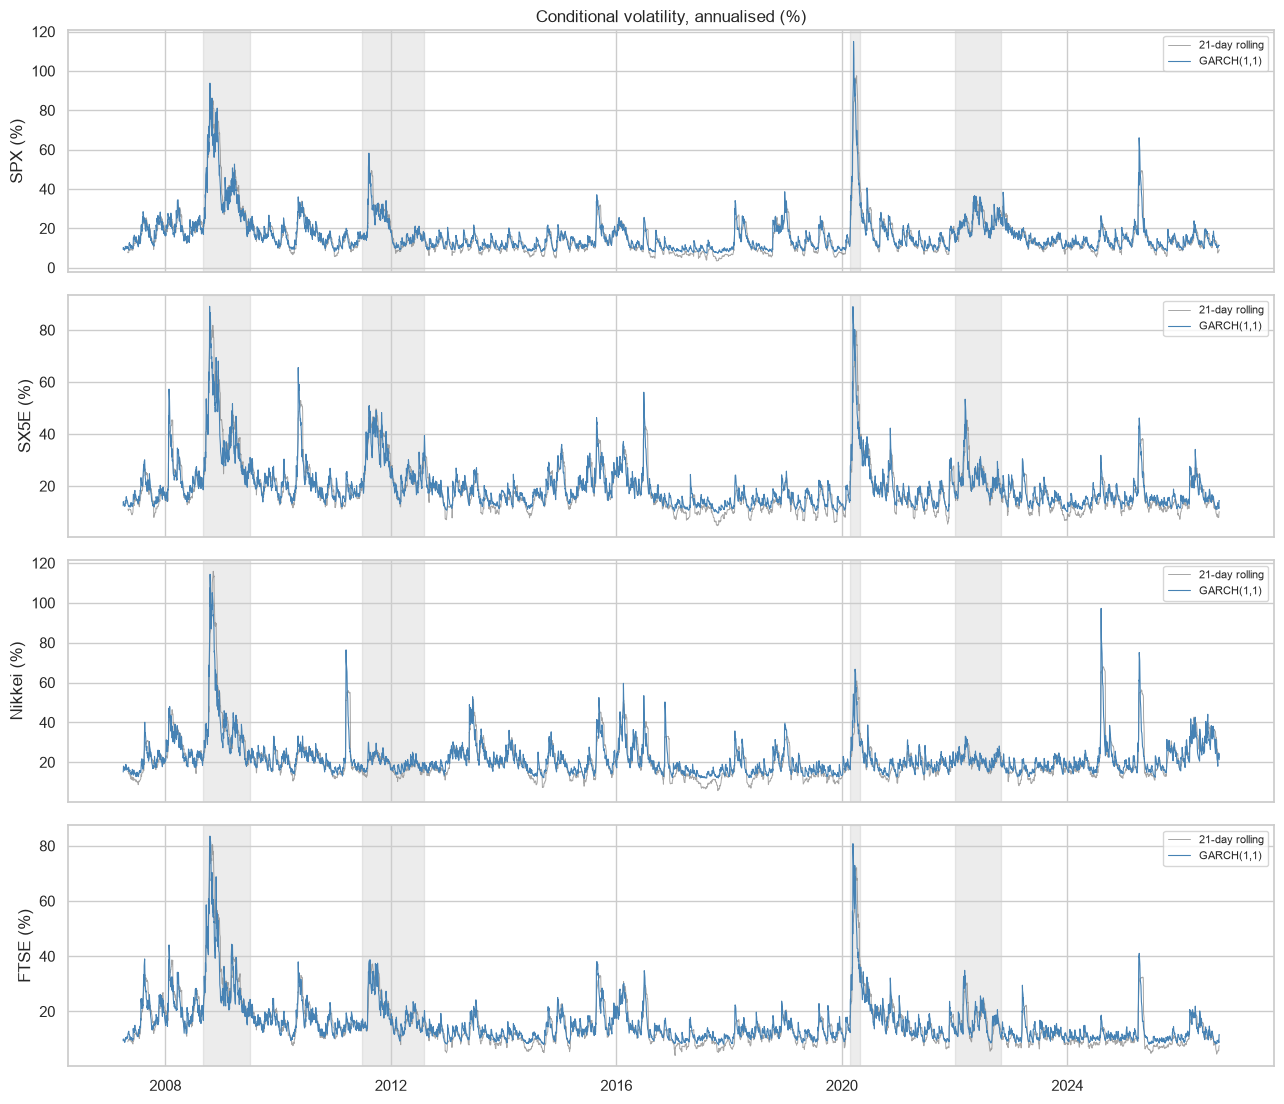

In [17]:
# Fitted conditional volatility vs rolling estimate
plot_conditional_volatility(garch_normal, returns=returns, window=21,
                            save_path="../outputs/conditional_volatility.png")

**Both estimators agree on shape** ： divergence would signal misspecification.

Three differences, all favouring the model: GARCH updates the day a shock arrives rather than waiting for it to enter a window; it decays smoothly instead of dropping when an observation exits at day 21; and it never discards old information entirely.

Those cliff-edge drops in the rolling estimate happen on days when nothing occurred in the market. Reason enough not to set risk limits from rolling standard deviations.

**The key distinction isn't visible on the chart:** the rolling estimate describes the past 21 days; $\hat\sigma_t$ uses only information dated $t-1$ and earlier — a genuine one-step-ahead forecast.

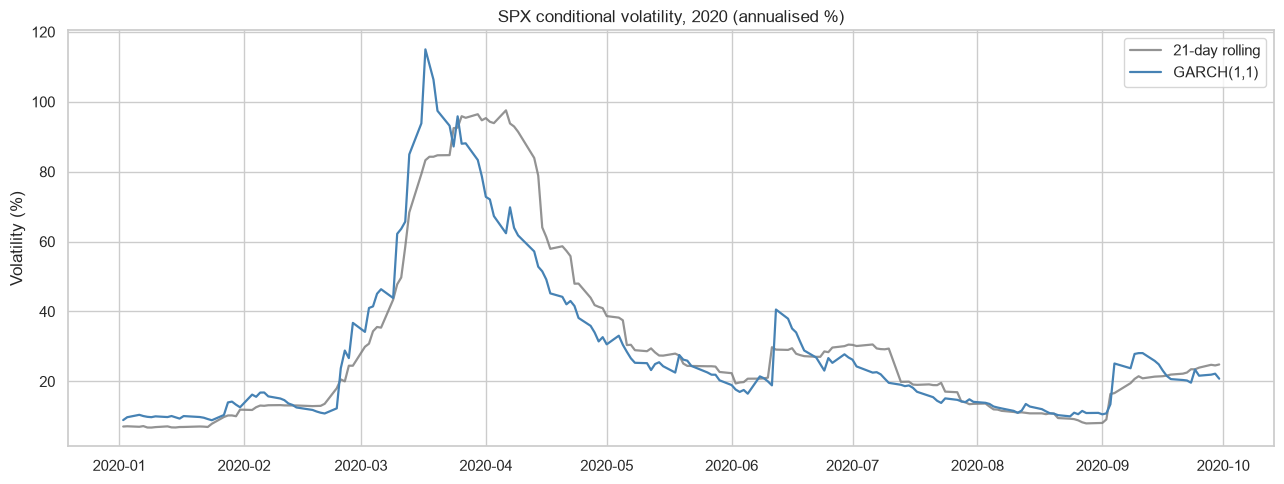

In [18]:
# Zoom on the COVID episode
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 5))

res = garch_normal["SPX"]
cond = (res.conditional_volatility * np.sqrt(252)).loc["2020-01-01":"2020-09-30"]
roll = (returns["SPX"].rolling(21).std() * np.sqrt(252)).loc["2020-01-01":"2020-09-30"]

ax.plot(roll.index, roll.values, linewidth=1.6, color="grey",
        label="21-day rolling", alpha=0.85)
ax.plot(cond.index, cond.values, linewidth=1.6, color="steelblue",
        label="GARCH(1,1)")

ax.set_title("SPX conditional volatility, 2020 (annualised %)")
ax.set_ylabel("Volatility (%)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/covid_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

**2020 separates the two estimators.**

| | GARCH | 21-day rolling |
|---|---|---|
| Onset | Late Feb | ~1 week later |
| Peak | 115% | 97% |
| Decay | Smooth | Step-like |

The −12.8% move of 16 March enters GARCH at full weight via
$\alpha\epsilon_{t-1}^2$; a rolling window dilutes it to $1/21$.

**The April plateau and early-May cliff are artefacts.** The grey line
sits flat near 95% while GARCH has already fallen to 65%, then drops
steeply as the March observations exit the window — on days when nothing
happened. A VaR limit set from a rolling standard deviation would loosen
on a purely calendrical trigger.

**Cost of responsiveness:** the single −6% day on 11 June lifts GARCH from
20% to 41% overnight. A large $\alpha$ buys reaction speed at the price of
sensitivity to isolated shocks.

# Stage 4 — Distributional Assumptions

Stage 3 assumed $z_t \sim N(0,1)$. Section 1.3 found excess kurtosis of 7.7–12.5 in the raw returns, which is a problem for that assumption — but not necessarily a fatal one.

GARCH generates fat unconditional tails on its own, through variance mixing: combining normals with time-varying $\sigma_t$ produces excess kurtosis even when $z_t$ is Gaussian. The question is whether it generates *enough*.

The test is the **standardised residuals** $\hat z_t = \hat\epsilon_t / \hat\sigma_t$. If mixing explains the tails, their kurtosis should be near zero. Whatever remains is the case for Student-$t$.

## 4.1 Standardised residuals under the normal model

In [19]:
# Kurtosis of standardised residuals
from scipy import stats

rows = []
for label, res in garch_normal.items():
    z = res.std_resid.dropna()          # epsilon_t / sigma_t
    raw_kurt = stats.kurtosis(returns[label])
    z_kurt = stats.kurtosis(z)
    rows.append({
        "Index": label,
        "Raw excess kurt": raw_kurt,
        "Std. resid kurt": z_kurt,
        "Absorbed by GARCH": raw_kurt - z_kurt,
        "% absorbed": f"{(raw_kurt - z_kurt) / raw_kurt:.0%}",
        "Std. resid skew": stats.skew(z),
    })

resid_kurt = pd.DataFrame(rows).set_index("Index").round(4)
resid_kurt

,Raw excess kurt,Std. resid kurt,Absorbed by GARCH,% absorbed,Std. resid skew
Index,,,,,
SPX,12.4719,1.8362,10.6357,85%,-0.6230
SX5E,7.7136,2.0309,5.6827,74%,-0.3833
Nikkei,8.2128,1.4276,6.7852,83%,-0.3681
FTSE,10.3690,1.7826,8.5864,83%,-0.4455


GARCH absorbs 74–85% of the excess kurtosis through variance mixing，confirming that most of the fat tails in §1.3 came from time-varying $\sigma_t$, not from the innovations.

**But 1.4–2.0 remains, in the same direction for all four indices.** Sampling noise would scatter around zero. Inverting $6/(\nu-4)$ implies $\nu \approx 7$–8, so we expect the $t$ estimates to land there.

**Skewness is untouched** (−0.37 to −0.62, barely changed from the raw series). This is structural: $\epsilon_{t-1}^2$ enters squared, so positive and negative shocks are identical to the model. Symmetric GARCH cannot generate skewness.

In [20]:
# GARCH(1,1) with Student-t innovations
garch_t = fit_all(returns, p=1, q=1, dist="t")

t_summary = summarise_fits(garch_t)
t_summary["nu"] = [garch_t[k].params["nu"] for k in t_summary.index]
t_summary

SPX      converged: True
SX5E     converged: True
Nikkei   converged: True
FTSE     converged: True


,omega,alpha,beta,alpha+beta,Half-life (days),Uncond. vol (%),Log-lik,AIC,BIC,nu
Index,,,,,,,,,,
SPX,0.0195,0.1459,0.8512,0.9971,240.0454,41.2673,"-6,543.8266","13,097.6532","13,130.1300",5.4165
SX5E,0.0336,0.1162,0.8708,0.9869,52.7212,25.4712,"-7,508.7325","15,027.4650","15,059.9234",5.6874
Nikkei,0.0617,0.1196,0.8548,0.9744,26.7004,24.6319,"-7,909.6583","15,829.3167","15,861.6514",6.6695
FTSE,0.0262,0.1318,0.8501,0.9818,37.8139,19.0707,"-6,394.9687","12,799.9373","12,832.4325",6.0119


**Student-$t$ wins on fit:** AIC falls 177–283 for one extra parameter; $LR \approx 570$ against a $\chi^2_1$ critical value of 6.63.

$\hat\nu$ lands at 5.4–6.7, below the 7–8 implied by residual kurtosis. Sample kurtosis is driven by a few extremes; MLE optimises the whole distribution.

**Persistence rises everywhere, and SPX breaks.** $\alpha+\beta$ goes 0.978 → 0.997, half-life 32 → 240 days, implied unconditional vol 41.3% vs a realised 19.8%. The §3.2 consistency check now fails.

Why: under normality a −12.8% day can only be accommodated by pushing $\sigma_t$ high. Student-$t$ lets the model call it a tail draw instead, so extremes get reattributed from variance to tail thickness — leaving a smoother, more persistent variance process. SPX is hit hardest because its kurtosis is highest.

**Don't take SPX's persistence at face value.** At 0.997 the model is near-IGARCH and the long-run variance is barely identified.

In [21]:
# Persistence shift and consistency check

comp = pd.DataFrame({
    "Persist (N)": garch_summary["alpha+beta"],
    "Persist (t)": t_summary["alpha+beta"],
    "HL (N)": garch_summary["Half-life (days)"],
    "HL (t)": t_summary["Half-life (days)"],
    "Uncond vol (N)": garch_summary["Uncond. vol (%)"],
    "Uncond vol (t)": t_summary["Uncond. vol (%)"],
    "Realised vol": [returns[k].std() * np.sqrt(252) for k in garch_summary.index],
    "nu": t_summary["nu"],
}).round(3)
comp

,Persist (N),Persist (t),HL (N),HL (t),Uncond vol (N),Uncond vol (t),Realised vol,nu
Index,,,,,,,,
SPX,0.9780,0.9970,31.8550,240.0450,18.8630,41.2670,19.7840,5.4170
SX5E,0.9760,0.9870,29.0970,52.7210,22.3530,25.4710,21.7750,5.6870
Nikkei,0.9670,0.9740,20.7150,26.7000,24.0480,24.6320,23.9460,6.6690
FTSE,0.9730,0.9820,25.4980,37.8140,17.3510,19.0710,17.8280,6.0120


Only SPX fails the check — SX5E, Nikkei and FTSE stay within 4 points of realised. The distributional fix is sound; its side-effect on persistence is localised to the most extreme-tailed series.


## 4.2 Residual diagnostics

AIC says the $t$ model fits better. This checks *where* the improvement is.

Each model is tested against the distribution it assumes — normal residuals against a normal, $t$ residuals against $t(\hat\nu)$. The scale is standardised, not raw: the $t$ distribution with $\nu$ degrees of freedom has variance $\nu/(\nu-2)$, which `arch` normalises to one.

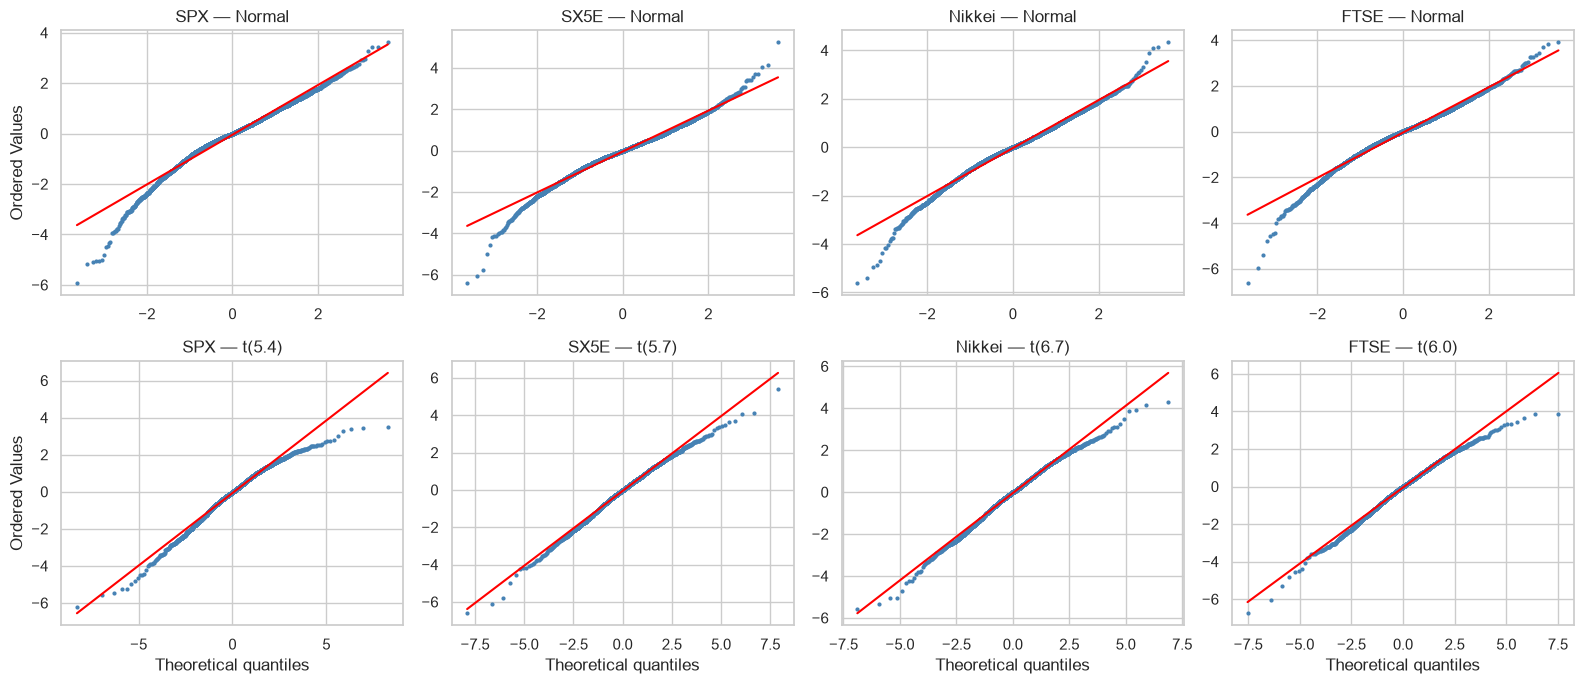

In [22]:
# Standardised residual QQ plots
plot_residual_qq(garch_normal, garch_t,
                 save_path="../outputs/residual_qq.png")

**Normal model:** excellent between $-2$ and $+2$ — GARCH absorbed most of the excess kurtosis. The left tail departs sharply (sample quantile near $-6$ at a $-3$ theoretical quantile) while the right tail barely does. The residual problem is *asymmetry*, not tail thickness per se.

**$t$ model:** now both tails sit *inside* the line — $t(5.4)$ is too fat for the data. MLE is fitting a symmetric distribution to asymmetric residuals: a $\nu$ low enough for the left tail overshoots on the right.

That compromise has a cost, and it lands on the variance equation. Rather than push $\nu$ lower still, the optimiser raises persistence to explain the extremes — which is why SPX's $\alpha+\beta$ reached 0.997.

**So the fix is incomplete.** Student-$t$ improves the likelihood decisively but treats an asymmetric problem as symmetric. The model needs to distinguish the *sign* of shocks, not just widen both tails.

## 4.3 Has the variance equation done its job?

The distributional checks above say nothing about whether GARCH captured the *dynamics*. Applying the §2.5 Ljung–Box test to $\hat z_t$ instead of $r_t$ closes that loop: $Q(r^2)$ ran 2,770–6,824 on raw returns; if the model works, the same statistic on standardised residuals should collapse.

In [23]:
# Ljung-Box on standardised residuals
z_sq = {label: res.std_resid.dropna() for label, res in garch_t.items()}
lb_resid = ljung_box_test(z_sq, lags=(5, 10, 22))
lb_resid

Q(r)   p(r)  Q(r^2)  p(r^2)
Index  Lags                               
SPX    5    13.5013 0.0191  5.3419  0.3756
       10   18.8958 0.0416 10.2792  0.4164
       22   33.6034 0.0539 19.8384  0.5931
SX5E   5     5.1130 0.4022  7.4917  0.1866
       10    6.2826 0.7910 10.2432  0.4194
       22   14.2325 0.8930 23.5624  0.3706
Nikkei 5     2.9438 0.7086 16.2949  0.0061
       10    4.1040 0.9425 18.7376  0.0437
       22   15.0132 0.8617 30.7072  0.1023
FTSE   5     2.8414 0.7244  7.7801  0.1688
       10    4.1629 0.9397 10.8900  0.3662
       22   11.4542 0.9677 22.4999  0.4304

**The variance equation is well specified.** $Q(z^2)$ at 22 lags falls from 2,770–6,824 on raw squared returns to 19.8–30.7 on standardised residuals — a reduction of over 99%. Eleven of twelve tests fail to reject white noise.

Two residual traces. The Nikkei is marginally significant at 5 and 10 lags ($p = 0.006$, $0.044$) but not at 22, consistent with the Japan-specific regimes visible in §2.3. SPX shows mild autocorrelation in $z_t$ itself at 5 lags — a mean-equation artefact of the kind identified in §2.5, not a variance problem.

Note the degrees of freedom are not adjusted for estimated parameters, making these $p$-values conservative. A failure to reject is therefore the stronger result.